In [82]:
import pandas as pd
import numpy as np
from dateutil import parser
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [83]:
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [84]:
cus = pd.read_csv("data/customer_behavior_retention.csv")
rev = pd.read_csv("data/film_revenue_performance.csv")
geo = pd.read_csv("data/geo_market.csv")
inv = pd.read_csv("data/inventory_operation.csv")
ssp = pd.read_csv("data/store_staff_performance.csv")
tbt = pd.read_csv("data/time_based_trends.csv")
unified = pd.read_csv("data/unified_dvdrental.csv")

In [85]:
cus.columns = cus.columns.str.title()
cus.rename(
    columns={
        'Customer_Id': 'Customer_ID', 
        'Country_Id': 'Country_ID', 
        'Store_Id': 'Store_ID'
    }, 
    inplace=True
)
cus['Active'] = cus['Active'].astype(bool)
cus.info()

<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         599 non-null    int64  
 1   Customer_Name       599 non-null    str    
 2   Active              599 non-null    bool   
 3   Country_ID          599 non-null    int64  
 4   Country             599 non-null    str    
 5   City                599 non-null    str    
 6   Store_ID            599 non-null    int64  
 7   Total_Spent         599 non-null    float64
 8   Total_Rents         599 non-null    int64  
 9   First_Rental_Date   599 non-null    str    
 10  Recent_Rental_Date  599 non-null    str    
 11  Rental_Months       599 non-null    int64  
dtypes: bool(1), float64(1), int64(5), str(5)
memory usage: 81.1 KB


In [86]:

def date_parser(date_str):
    try:
        return parser.parse(date_str, dayfirst=True)
    except Exception:
        return pd.NaT

cus['First_Rental_Date'] = cus['First_Rental_Date'].apply(date_parser)
cus['Recent_Rental_Date'] = cus['Recent_Rental_Date'].apply(date_parser)

cus.info()
cus

<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         599 non-null    int64         
 1   Customer_Name       599 non-null    str           
 2   Active              599 non-null    bool          
 3   Country_ID          599 non-null    int64         
 4   Country             599 non-null    str           
 5   City                599 non-null    str           
 6   Store_ID            599 non-null    int64         
 7   Total_Spent         599 non-null    float64       
 8   Total_Rents         599 non-null    int64         
 9   First_Rental_Date   599 non-null    datetime64[us]
 10  Recent_Rental_Date  599 non-null    datetime64[us]
 11  Rental_Months       599 non-null    int64         
dtypes: bool(1), datetime64[us](2), float64(1), int64(5), str(3)
memory usage: 69.4 KB


,Customer_ID,Customer_Name,Active,Country_ID,Country,City,Store_ID,Total_Spent,Total_Rents,First_Rental_Date,Recent_Rental_Date,Rental_Months
0,155,Gail Knight,True,91,Switzerland,Bern,1,106.76,24,2005-06-15,2006-02-14,9
1,294,Shelly Watts,True,103,United States,Dayton,2,105.77,23,2005-06-07,2005-08-23,2
2,506,Leslie Seward,True,45,Indonesia,Pontianak,2,123.72,28,2005-06-15,2005-08-23,3
3,30,Melissa King,True,92,Taiwan,Lungtan,1,123.66,34,2005-06-17,2005-08-23,3
4,590,Seth Hannon,True,11,Bahrain,al-Manama,2,108.76,24,2005-06-15,2006-02-14,9
...,...,...,...,...,...,...,...,...,...,...,...,...
594,55,Doris Reed,True,80,Russian Federation,Balaiha,2,84.81,19,2005-06-16,2005-08-22,3
595,42,Carolyn Perez,True,94,Thailand,Pak Kret,2,111.71,29,2005-06-16,2006-02-14,9
596,342,Harold Martino,True,15,Brazil,Boa Vista,1,130.68,32,2005-06-18,2005-08-23,3
597,435,Ricky Shelby,True,23,China,Junan,2,78.77,23,2005-06-15,2005-08-22,3


In [87]:
rev.columns = rev.columns.str.title()
rev['Last_Rental_Date'] = rev['Last_Rental_Date'].apply(date_parser)
rev.rename(
    columns={
        'Film_Id': 'Film_ID', 
        'Category_Id': 'Category_ID'
    }, 
    inplace=True
)

rev.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Film_ID                 1000 non-null   int64         
 1   Film                    1000 non-null   str           
 2   Length                  1000 non-null   int64         
 3   Category_ID             1000 non-null   int64         
 4   Category                1000 non-null   str           
 5   Total_Revenue           1000 non-null   float64       
 6   Total_Rent              1000 non-null   int64         
 7   Average_Rental_Revenue  1000 non-null   float64       
 8   Last_Rental_Date        958 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(4), str(2)
memory usage: 90.7 KB


In [88]:
geo.columns = geo.columns.str.title()
geo.rename(columns={'Country_Id': 'Country_ID'}, inplace=True)

geo.info()

<class 'pandas.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country_ID         597 non-null    int64  
 1   Country            597 non-null    str    
 2   City               597 non-null    str    
 3   Total_Geo_Rent     597 non-null    int64  
 4   Total_Geo_Revenue  597 non-null    float64
 5   Unique_Customers   597 non-null    int64  
 6   Top_Category       597 non-null    str    
dtypes: float64(1), int64(3), str(3)
memory usage: 46.2 KB


In [89]:
inv.columns = inv.columns.str.title()
inv['Last_Rental_Date'] = inv['Last_Rental_Date'].apply(date_parser)
inv.rename(
    columns={
        'Film_Id': 'Film_ID', 
        'Store_Id': 'Store_ID',
        'Category_Id': 'Category_ID'
    }, 
    inplace=True
)

inv.info()

<class 'pandas.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Film_ID                  1563 non-null   int64         
 1   Film_Title               1563 non-null   str           
 2   Category_ID              1563 non-null   int64         
 3   Category                 1563 non-null   str           
 4   Store_ID                 1521 non-null   float64       
 5   Inventory_Count          1563 non-null   int64         
 6   Total_Rent               1563 non-null   int64         
 7   Total_Revenue            1521 non-null   float64       
 8   Last_Rental_Date         1521 non-null   datetime64[us]
 9   Average_Rental_Duration  1563 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(5), str(2)
memory usage: 153.9 KB


In [90]:
ssp.columns = ssp.columns.str.title()
ssp.rename(
    columns={
        'Staff_Id': 'Staff_ID', 
        'Store_Id': 'Store_ID'
    }, 
    inplace=True
)

ssp.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Store_ID                 2 non-null      int64  
 1   Staff_ID                 2 non-null      int64  
 2   Staff_Name               2 non-null      str    
 3   Total_Rentals_Processed  2 non-null      int64  
 4   Total_Revenue_Collected  2 non-null      float64
 5   Unique_Customers_Served  2 non-null      int64  
 6   Average_Daily_Rent       2 non-null      int64  
dtypes: float64(1), int64(5), str(1)
memory usage: 268.0 bytes


In [91]:
tbt.columns = tbt.columns.str.title()

tbt.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  4 non-null      int64  
 1   Month                 4 non-null      str    
 2   Total_Rentals         4 non-null      int64  
 3   Total_Revenue         4 non-null      float64
 4   Unique_Customers      4 non-null      int64  
 5   Average_Rent_Revenue  4 non-null      float64
dtypes: float64(2), int64(3), str(1)
memory usage: 360.0 bytes


In [92]:
unified.columns = unified.columns.str.title()
unified['Rental_Date'] = unified['Rental_Date'].apply(date_parser)
unified['Payment_Date'] = unified['Payment_Date'].apply(date_parser)
unified.rename(
    columns={
        'Rental_Id': 'Rental_ID',
        'Customer_Id': 'Customer_ID', 
        'Film_Id': 'Film_ID', 
        'Staff_Id': 'Staff_ID',
        'Store_Id': 'Store_ID',
        'Inventory_Id': 'Inventory_ID'
    }, 
    inplace=True
)

unified.info()

<class 'pandas.DataFrame'>
RangeIndex: 16048 entries, 0 to 16047
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Rental_ID        16048 non-null  int64         
 1   Rental_Date      16048 non-null  datetime64[us]
 2   Rental_Month     16048 non-null  str           
 3   Customer_ID      16048 non-null  int64         
 4   Customer_Name    16048 non-null  str           
 5   Total_Rents      16048 non-null  int64         
 6   Active           16048 non-null  int64         
 7   City             16048 non-null  str           
 8   Country          16048 non-null  str           
 9   Film_ID          16048 non-null  int64         
 10  Film_Title       16048 non-null  str           
 11  Category         16048 non-null  str           
 12  Length           16048 non-null  int64         
 13  Inventory_ID     16048 non-null  int64         
 14  Store_ID         16048 non-null  int64         
 

In [93]:
unified['Active'] = unified['Active'].astype(bool)
unified.head()

,Rental_ID,Rental_Date,Rental_Month,Customer_ID,Customer_Name,Total_Rents,Active,City,Country,Film_ID,Film_Title,Category,Length,Inventory_ID,Store_ID,Staff_ID,Staff_Name,Payment_Amount,Payment_Date,Rental_Duration
0,1,2005-05-24,May,130,Charlotte Hunter,1,True,guas Lindas de Gois,Brazil,80,Blanket Beverly,Family,148,367,1,1,Mike Hillyer,0.00,NaT,7
1,2,2005-05-24,May,459,Tommy Collazo,1,True,Qomsheh,Iran,333,Freaky Pocus,Music,126,1525,1,1,Mike Hillyer,0.00,NaT,7
2,3,2005-05-24,May,408,Manuel Murrell,1,True,Jaffna,Sri Lanka,373,Graduate Lord,Children,156,1711,1,1,Mike Hillyer,0.00,NaT,7
3,4,2005-05-24,May,333,Andrew Purdy,1,True,Baku,Azerbaijan,535,Love Suicides,Horror,181,2452,2,2,Jon Stephens,0.00,NaT,6
4,5,2005-05-24,May,222,Delores Hansen,1,True,Jaroslavl,Russian Federation,450,Idols Snatchers,Children,84,2079,1,1,Mike Hillyer,0.00,NaT,5


In [94]:
merge_df1 = pd.merge(inv, rev, on=["Film_ID", "Category_ID","Category","Total_Revenue","Total_Rent", "Last_Rental_Date"], how='left')
merge_df1.info()
merge_df1.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Film_ID                  1563 non-null   int64         
 1   Film_Title               1563 non-null   str           
 2   Category_ID              1563 non-null   int64         
 3   Category                 1563 non-null   str           
 4   Store_ID                 1521 non-null   float64       
 5   Inventory_Count          1563 non-null   int64         
 6   Total_Rent               1563 non-null   int64         
 7   Total_Revenue            1521 non-null   float64       
 8   Last_Rental_Date         1521 non-null   datetime64[us]
 9   Average_Rental_Duration  1563 non-null   int64         
 10  Film                     395 non-null    str           
 11  Length                   395 non-null    float64       
 12  Average_Rental_Revenue   395 non-null    floa

Film_ID                       0
Film_Title                    0
Category_ID                   0
Category                      0
Store_ID                     42
Inventory_Count               0
Total_Rent                    0
Total_Revenue                42
Last_Rental_Date             42
Average_Rental_Duration       0
Film                       1168
Length                     1168
Average_Rental_Revenue     1168
dtype: int64

In [95]:
# merging geographical and customer data

merge_df2 = pd.merge(geo, cus, on=["Country_ID", "Country", "City"], how='inner')
merge_df2.info()


<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Country_ID          599 non-null    int64         
 1   Country             599 non-null    str           
 2   City                599 non-null    str           
 3   Total_Geo_Rent      599 non-null    int64         
 4   Total_Geo_Revenue   599 non-null    float64       
 5   Unique_Customers    599 non-null    int64         
 6   Top_Category        599 non-null    str           
 7   Customer_ID         599 non-null    int64         
 8   Customer_Name       599 non-null    str           
 9   Active              599 non-null    bool          
 10  Store_ID            599 non-null    int64         
 11  Total_Spent         599 non-null    float64       
 12  Total_Rents         599 non-null    int64         
 13  First_Rental_Date   599 non-null    datetime64[us]
 14  Recen

In [96]:
# Merging staff and store performance to revenue and inventory (merge_ff1)
merge_df3 = pd.merge(merge_df1, ssp, on="Store_ID", how='inner')
merge_df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1521 entries, 0 to 1520
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Film_ID                  1521 non-null   int64         
 1   Film_Title               1521 non-null   str           
 2   Category_ID              1521 non-null   int64         
 3   Category                 1521 non-null   str           
 4   Store_ID                 1521 non-null   float64       
 5   Inventory_Count          1521 non-null   int64         
 6   Total_Rent               1521 non-null   int64         
 7   Total_Revenue            1521 non-null   float64       
 8   Last_Rental_Date         1521 non-null   datetime64[us]
 9   Average_Rental_Duration  1521 non-null   int64         
 10  Film                     395 non-null    str           
 11  Length                   395 non-null    float64       
 12  Average_Rental_Revenue   395 non-null    floa

In [97]:
merge_df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1521 entries, 0 to 1520
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Film_ID                  1521 non-null   int64         
 1   Film_Title               1521 non-null   str           
 2   Category_ID              1521 non-null   int64         
 3   Category                 1521 non-null   str           
 4   Store_ID                 1521 non-null   float64       
 5   Inventory_Count          1521 non-null   int64         
 6   Total_Rent               1521 non-null   int64         
 7   Total_Revenue            1521 non-null   float64       
 8   Last_Rental_Date         1521 non-null   datetime64[us]
 9   Average_Rental_Duration  1521 non-null   int64         
 10  Film                     395 non-null    str           
 11  Length                   395 non-null    float64       
 12  Average_Rental_Revenue   395 non-null    floa

In [98]:
merge_df2

,Country_ID,Country,City,Total_Geo_Rent,Total_Geo_Revenue,Unique_Customers,Top_Category,Customer_ID,Customer_Name,Active,Store_ID,Total_Spent,Total_Rents,First_Rental_Date,Recent_Rental_Date,Rental_Months
0,79,Runion,Saint-Denis,46,211.55,1,Sci-Fi,148,Eleanor Hunt,True,1,211.55,45,2005-06-15,2005-08-23,3
1,103,United States,Cape Coral,45,208.58,1,Animation,526,Karl Seal,True,2,208.58,42,2005-06-15,2005-08-23,3
2,15,Brazil,Santa Brbara dOeste,39,194.61,1,Drama,178,Marion Snyder,True,2,194.61,39,2005-06-15,2006-02-14,9
3,67,Netherlands,Apeldoorn,39,191.62,1,Games,137,Rhonda Kennedy,True,2,191.62,38,2005-06-18,2005-08-23,3
4,13,Belarus,Molodetno,42,189.60,1,Drama,144,Clara Shaw,True,1,189.60,40,2005-06-16,2005-08-23,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,23,China,Enshi,14,49.88,1,Drama,110,Tiffany Jordan,True,2,49.88,12,2005-06-16,2005-08-22,3
595,3,American Samoa,Tafuna,20,47.85,1,Sports,320,Anthony Schwab,True,2,47.85,15,2005-06-07,2005-08-22,2
596,103,United States,Tallahassee,15,37.87,1,Sci-Fi,248,Caroline Bowman,True,1,37.87,13,2005-06-17,2005-08-22,3
597,23,China,Fuzhou,14,32.90,1,Family,281,Leona Obrien,True,2,32.90,10,2005-08-07,2005-08-21,2


In [99]:

# Dealing with outliers

Q1 = unified.select_dtypes(include=["number"]).quantile(0.25)
Q3 = unified.select_dtypes(include=["number"]).quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep rows where ALL numeric features fall within the bounds
numeric_cols = unified.select_dtypes(include=["number"]).columns
condition = ((unified[numeric_cols] >= lower_bound) & (unified[numeric_cols] <= upper_bound)).all(axis=1)

new_unified = unified[condition]
new_unified.info()

<class 'pandas.DataFrame'>
Index: 16040 entries, 0 to 16047
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Rental_ID        16040 non-null  int64         
 1   Rental_Date      16040 non-null  datetime64[us]
 2   Rental_Month     16040 non-null  str           
 3   Customer_ID      16040 non-null  int64         
 4   Customer_Name    16040 non-null  str           
 5   Total_Rents      16040 non-null  int64         
 6   Active           16040 non-null  bool          
 7   City             16040 non-null  str           
 8   Country          16040 non-null  str           
 9   Film_ID          16040 non-null  int64         
 10  Film_Title       16040 non-null  str           
 11  Category         16040 non-null  str           
 12  Length           16040 non-null  int64         
 13  Inventory_ID     16040 non-null  int64         
 14  Store_ID         16040 non-null  int64         
 15  S

In [100]:
# Data Understanding (on the unified dataset)

In [101]:
# How many records and columns are in the final merged dataset?

print("The total records and columns are:", new_unified.shape, "respectively")


The total records and columns are: (16040, 20) respectively


In [102]:
# What data types exist (numerical, categorical, datetime)?
type = new_unified.info()

<class 'pandas.DataFrame'>
Index: 16040 entries, 0 to 16047
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Rental_ID        16040 non-null  int64         
 1   Rental_Date      16040 non-null  datetime64[us]
 2   Rental_Month     16040 non-null  str           
 3   Customer_ID      16040 non-null  int64         
 4   Customer_Name    16040 non-null  str           
 5   Total_Rents      16040 non-null  int64         
 6   Active           16040 non-null  bool          
 7   City             16040 non-null  str           
 8   Country          16040 non-null  str           
 9   Film_ID          16040 non-null  int64         
 10  Film_Title       16040 non-null  str           
 11  Category         16040 non-null  str           
 12  Length           16040 non-null  int64         
 13  Inventory_ID     16040 non-null  int64         
 14  Store_ID         16040 non-null  int64         
 15  S

In [103]:
# Are there missing or null values? How will you handle them?

new_unified.isnull().sum()


Rental_ID             0
Rental_Date           0
Rental_Month          0
Customer_ID           0
Customer_Name         0
Total_Rents           0
Active                0
City                  0
Country               0
Film_ID               0
Film_Title            0
Category              0
Length                0
Inventory_ID          0
Store_ID              0
Staff_ID              0
Staff_Name            0
Payment_Amount        0
Payment_Date       1452
Rental_Duration       0
dtype: int64

In [104]:
new_unified = unified.dropna()

new_unified.info()

<class 'pandas.DataFrame'>
Index: 14596 entries, 1156 to 16047
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Rental_ID        14596 non-null  int64         
 1   Rental_Date      14596 non-null  datetime64[us]
 2   Rental_Month     14596 non-null  str           
 3   Customer_ID      14596 non-null  int64         
 4   Customer_Name    14596 non-null  str           
 5   Total_Rents      14596 non-null  int64         
 6   Active           14596 non-null  bool          
 7   City             14596 non-null  str           
 8   Country          14596 non-null  str           
 9   Film_ID          14596 non-null  int64         
 10  Film_Title       14596 non-null  str           
 11  Category         14596 non-null  str           
 12  Length           14596 non-null  int64         
 13  Inventory_ID     14596 non-null  int64         
 14  Store_ID         14596 non-null  int64         
 15

In [105]:
# Are there duplicate records? How will you resolve them?
new_unified.duplicated().sum()


np.int64(0)

In [106]:
# Distribution Analysis
# What is the distribution of:
#     Rental revenue?
#     Number of rentals per customer?
#     Rental duration?
#     Payments per transaction?

count   1521.00
mean      40.31
std       21.76
min        4.95
25%       22.94
50%       36.94
75%       53.86
max      121.86
Name: Total_Revenue, dtype: float64


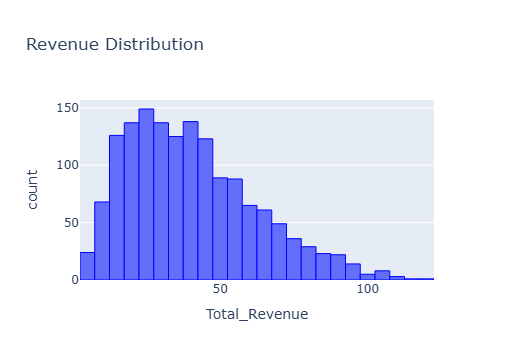

In [107]:
# What is the distribution of Rental revenue?
print(inv['Total_Revenue'].describe())

fig1 = px.histogram(
    inv,
    x='Total_Revenue',
    nbins=50
    ,
    title='Revenue Distribution'
)
fig1.update_traces(
    marker_line_color='blue',
    marker_line_width=1
)
fig1.show()

In [108]:
# What is the distribution of the number of rentals per customer?

cus.groupby('Customer_Name')['Total_Rents'].sum().sort_values(ascending=False).reset_index(name='Rentals')



,Customer_Name,Rentals
0,Eleanor Hunt,45
1,Karl Seal,42
2,Clara Shaw,40
3,Marcia Dean,39
4,Marion Snyder,39
...,...,...
594,Kay Caldwell,13
595,Daniel Cabral,13
596,Tiffany Jordan,12
597,Leona Obrien,10


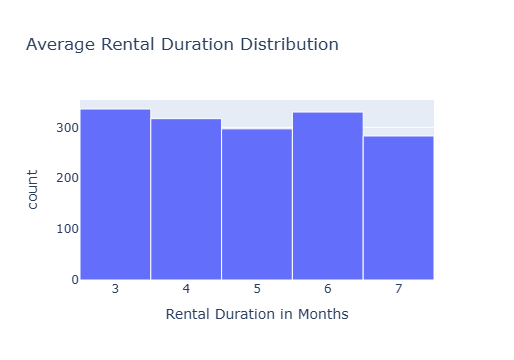

In [109]:
# What is the distribution of Rental duration?

fig2 = px.histogram(
    inv,
    x='Average_Rental_Duration',
    nbins=5
    ,
    title='Average Rental Duration Distribution'
)
fig2.update_traces(
    marker_line_color='white',
    marker_line_width=1
)

fig2.update_layout(
    xaxis_title="Rental Duration in Months"
)

fig2.show()


In [110]:
# What is the distribution of Payments per transaction?

inv.head()

,Film_ID,Film_Title,Category_ID,Category,Store_ID,Inventory_Count,Total_Rent,Total_Revenue,Last_Rental_Date,Average_Rental_Duration
0,535,Love Suicides,11,Horror,1.00,4,20,22.85,2005-08-23,6
1,450,Idols Snatchers,3,Children,2.00,4,20,52.85,2005-08-23,5
2,759,Salute Apollo,13,New,2.00,4,19,74.84,2005-08-22,4
3,396,Hanging Deep,7,Drama,2.00,4,19,92.85,2005-08-20,5
4,875,Talented Homicide,15,Sports,2.00,4,19,22.85,2005-08-17,6


In [111]:
# Identify outliers in:
# Revenue
# Rentals
# Spending per customer
# Rental duration


num_cols = ["Total_Rents", "Payment_Amount", "Rental_Duration"]
Q1 = new_unified[num_cols].quantile(0.25)
Q3 = new_unified[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bond = Q1 - 1.5*IQR
upper_bond = Q3 + 1.5*IQR
outliers = (new_unified[num_cols] < lower_bond) | (new_unified[num_cols] > upper_bond)
outliers.sum()


Total_Rents          0
Payment_Amount     780
Rental_Duration      0
dtype: int64

In [112]:
new_unified.shape
new_unified.isnull().sum()

Rental_ID          0
Rental_Date        0
Rental_Month       0
Customer_ID        0
Customer_Name      0
Total_Rents        0
Active             0
City               0
Country            0
Film_ID            0
Film_Title         0
Category           0
Length             0
Inventory_ID       0
Store_ID           0
Staff_ID           0
Staff_Name         0
Payment_Amount     0
Payment_Date       0
Rental_Duration    0
dtype: int64

In [113]:
#Saving the cleaned data as csv

new_unified.to_csv('data/cleaned_unified_data.csv', index=False)

In [114]:
# Trend & Pattern Analysis


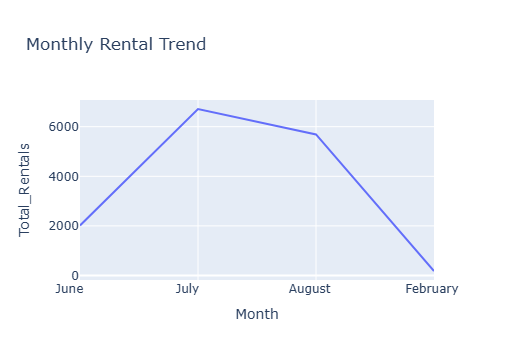

In [115]:
# How do rentals change over time


px.line(
    tbt,
    x='Month',
    y='Total_Rentals',
    title='Monthly Rental Trend'
).show()



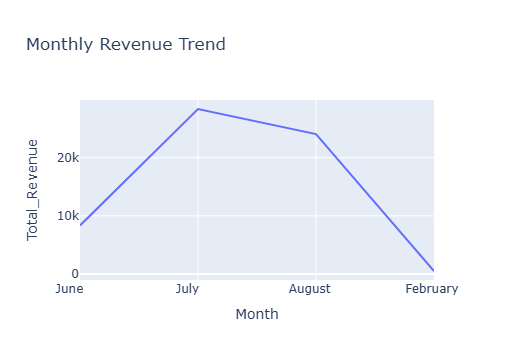

In [116]:
# How do revenue change over time

px.line(
    tbt,
    x='Month',
    y='Total_Revenue',
    title='Monthly Revenue Trend'
).show()

In [117]:
# Which months perform best and worst
monthly_performance = tbt.groupby('Month')['Total_Revenue'].sum().sort_values(ascending=False)
monthly_performance

Month
July        28377.87
August      24070.14
June         8349.85
February      514.18
Name: Total_Revenue, dtype: float64

In [118]:
# Which film categories show growth or decline over time?
# What time of day sees the highest rental activity?



In [119]:
# Customer Insight

In [120]:
# What percentage of customers are repeat renters?

customer_counts = cus.groupby('Customer_ID').size()

repeat_customers = customer_counts[customer_counts > 1]

total_customers = len(customer_counts)
repeat_count = len(repeat_customers)
repeat_percentage = (repeat_count / total_customers) * 100

print(f"Total Customers: {total_customers}")
print(f"Repeat Customers: {repeat_count}")
print(f"Repeat Rental Rate: {repeat_percentage:.2f}%")

Total Customers: 599
Repeat Customers: 0
Repeat Rental Rate: 0.00%


In [121]:
# What is the average spending per customer?
avg_spending = cus['Total_Spent'].sum() / cus['Customer_ID'].nunique()

print(f"Average Spending per Customer: ${avg_spending:.2f}")



Average Spending per Customer: $102.36


In [122]:
# What is the average time gap between rentals?

print("Average Time Gap:", (cus['Recent_Rental_Date'] - cus['First_Rental_Date']).mean())



Average Time Gap: 112 days 04:38:51.886477


In [123]:
# How many customers are inactive or at churn risk?

notactive = (cus['Active'] == False).sum()
print(f"There are {notactive} Inactive customers")



There are 15 Inactive customers


In [124]:
# Film & Category Insights

In [125]:
# Which films generate the most revenue per rental?

top_revenue_films = (rev.groupby("Film")["Average_Rental_Revenue"].sum().sort_values( ascending=False)
)

print("--- Top 5 Films by Revenue Per Rental ---")
print(top_revenue_films.head(5))


--- Top 5 Films by Revenue Per Rental ---
Film
Backlash Undefeated   8.80
Hustler Party         8.67
Tycoon Gathering      8.66
Telegraph Voyage      8.63
Caribbean Liberty     8.37
Name: Average_Rental_Revenue, dtype: float64


In [126]:
# Which categories have the highest average rental price?

top_revenue_categories = (rev.groupby("Category")["Average_Rental_Revenue"].sum().sort_values( ascending=False)
)

print("--- Top 5 Film Categories by Revenue Per Rental ---")
print(top_revenue_categories.head(5))

--- Top 5 Film Categories by Revenue Per Rental ---
Category
Sports    334.78
Foreign   280.59
New       269.56
Games     264.90
Family    261.82
Name: Average_Rental_Revenue, dtype: float64


In [127]:
#Are longer movies rented more or less frequently?
film_length_analysis = (rev.groupby(["Film", "Length"])["Total_Rent"].sum().sort_values(ascending=False).reset_index(name="Total Rents"))
film_length_analysis.head(15)


,Film,Length,Total Rents
0,Bucket Brotherhood,133,34
1,Rocketeer Mother,178,33
2,Scalawag Duck,183,32
3,Forward Temple,90,32
4,Grit Clockwork,137,32
5,Ridgemont Submarine,46,32
6,Juggler Hardly,54,32
7,Zorro Ark,50,31
8,Network Peak,75,31
9,Wife Turn,183,31


In [128]:
# Which films have high demand but low inventory?

# demand_threshold = rev['Total_Rent'].median()
# inventory_threshold = rev['Total_Revenue'].median()

# # 3. Apply boolean filtering to find films that meet both conditions
# high_demand_low_inventory = rev[
#     (rev['Total_Rent'] > demand_threshold) & 
#     (rev['Total_Revenue'] < inventory_threshold)
# ]

# print(high_demand_low_inventory)

# # rev.info()

In [129]:
# Store & Staff Insights

In [130]:
# Which store is more profitable?
profitability = (ssp.groupby("Store_ID")["Total_Revenue_Collected"].sum()
    .reset_index(name="Total_Revenue_Collected")
    .sort_values(by="Total_Revenue_Collected", ascending=False)
)

print("Store Profitability")
print(profitability)


Store Profitability
   Store_ID  Total_Revenue_Collected
1         2                 31059.92
0         1                 30252.12


In [131]:
# Which staff member is the most efficient?
efficiency = (ssp.groupby("Staff_Name")["Total_Rentals_Processed"].sum()
    .reset_index(name="Total_Rentals_Processed")
    .sort_values(by="Total_Rentals_Processed", ascending=False)
)

print("Staff Efficiency")
print(efficiency)


Staff Efficiency
     Staff_Name  Total_Rentals_Processed
0  Jon Stephens                     7304
1  Mike Hillyer                     7292


In [132]:
# What staffing patterns correlate with higher revenue?

In [133]:
# Geographic Insights

In [134]:
# Which countries are the most profitable?
top_revenue_countries = (geo.groupby("Country")["Total_Geo_Revenue"].sum().sort_values( ascending=False))

print("--- Top 10 Countries by Revenue ---")
print(top_revenue_countries.head(10))


--- Top 10 Countries by Revenue ---
Country
India                6032.79
China                5247.04
United States        3694.27
Japan                3121.52
Mexico               2984.82
Brazil               2919.19
Russian Federation   2765.62
Philippines          2219.70
Turkey               1498.49
Indonesia            1352.69
Name: Total_Geo_Revenue, dtype: float64


In [135]:
# Which cities are the most profitable?
top_revenue_cities = (geo.groupby("City")["Total_Geo_Revenue"].sum().sort_values( ascending=False)
)

print("--- Top 10 Cities by Revenue ---")
print(top_revenue_cities.head(10))


--- Top 10 Cities by Revenue ---
City
Saint-Denis           211.55
Cape Coral            208.58
Santa Brbara dOeste   194.61
Apeldoorn             191.62
Molodetno             189.60
Qomsheh               183.63
London                174.54
Memphis               167.67
Richmond Hill         167.62
Tanza                 166.61
Name: Total_Geo_Revenue, dtype: float64


In [136]:
# Which regions show the fastest growth?



Validation & Data Quality Checks

Do totals from the unified dataset match totals from original SQL outputs?
No, the unified dataset has more outputs.

Are revenue and rental counts consistent across time, geography, and film dimensions?
No. Since we don't have the same sizes of geo-locations and number of films, the counts are a little different.

Are any records missing critical identifiers (film, customer, date)?
Yes, some tables in the database are not relational. This made merging difficult, and produced some duplicates.


Business Recommendations & Strategic Insights
    Revenue Growth Strategy
The top 3 film categories are Sports, Foreign, and New because they yield the highest revenue (334.78, 280.59, and 269.56, respectively). We recommend promotions of some under-performing movies. The management should also have the geographical preferences of these categories in mind. 

    Customer Retention Strategy
The firm should introduce retaining some percentage of new films for top-customers. They can also reduce the late fees for them. The management should arrange free/subsidised rentals for Chun-risk customers. Enticing inactive ones with notifications of trending movies will also work. Lastly, introducing a multi-tiered loyalty program will accommodate all active customers, and the levels will accord deserving incentives based on their activities. 

    Inventory Optimization
Movies like Bucket Brotherhood (34), Rocketeer Mother (33), and Scalawag Duck (32) should be restocked often because they have a high volume of rentals. Rentals of Apollo Teen, Walls Artist, Wake Jaws, Volume House, and Ark Ridgemont should be discontinued because they have zero turnover. Regions influence the number of films rented, so inventory should differ by region. 

    Store & Staff Performance Improvement
Although both stores attended to the same number of unique customers, Jon Stephens of store 2 is more efficient with 7304 rentals processed and $31059.92 generated in revenue. Seminars where staff exchange ideas and patterns should be encouraged. Also, professional training will improve staff efficiency. 

    Market Expansion & Localization
Saint-Denis (211.55), Cape Coral (208.58), and (Santa Brbara dOeste (194.61) recorded the  highest returns. Management should always consider the category preferences of these regions before offering films to stores. We recommend physical rental kiosks in top-tier cities showing high spending but low overall customer counts. Also, targeted ad to the top 3 high-yield countries to lower customer acquisition costs.


Executive Summary
We discovered that the revenue generation is highly centralized with less than 20% of the customers influencing the sales. There is also a high replacement cost which can discourage customers from patronizing the business. We also noticed some films have never been rented. More importantly, both stores have close performance and efficiency.

Some of the business risks include:
    High acquisition costs
    Financial capital is locked up in non-performing
    High-replacement-cost deadstock
    No real-time inventory monitoring tools across stores

Recommendations
    Launch a tiered customer Loyalty Program
    Identify and offer unrented titles for discounted sales
    Shift overstock copies of high-demand genres between Store 1 and Store 2 dynamically
    Automated reminders, and custom promotions 
